### Pobranie danych z csv

In [1]:
import pandas as pd

df_allnba1 = pd.read_csv('../data/processed/allnba_final_expanded.csv')
df_rookie = pd.read_csv('../data/processed/rookie_final_expanded.csv')


In [2]:
# df_allnba.shape

### Dodanie kolumny Games Started


In [3]:
gs_data_raw = pd.read_csv('../data/raw/gs_stat.csv')
df_gs_stat = gs_data_raw.copy()
df_gs_stat.columns

Index(['PLAYER_NAME', 'GS', 'SEASON'], dtype='object')

In [4]:
from unidecode import unidecode

df_gs_stat['PLAYER_NAME'] = df_gs_stat['PLAYER_NAME'].apply(unidecode).str.strip()
df_allnba = pd.merge(df_allnba1, df_gs_stat, on=['PLAYER_NAME', 'SEASON'], how='left')
# df_allnba[df_allnba['GS'].isna()]['PLAYER_NAME'].unique()


In [5]:
df_allnba['GS'] = df_allnba['GS'].fillna(0)
df_allnba[df_allnba['GS'].isna()]['PLAYER_NAME'].unique()

array([], dtype=object)

### Odczytanie danych o nagrodach

In [6]:
path_voting_allnba = '../data/raw/voting_allnba.csv'
path_voting_rookie = '../data/raw/voting_rookie.csv'

df_voting_allnba_raw = pd.read_csv(path_voting_allnba)
df_voting_rookie_raw = pd.read_csv(path_voting_rookie)

df_voting_allnba = df_voting_allnba_raw.copy()
df_voting_rookie = df_voting_rookie_raw.copy()

### Modyfikacja kolumn

In [7]:
for col in ['PTS', 'REB', 'AST', 'STL', 'MIN']:
    df_allnba[f'{col}_PG'] = df_allnba[col] / df_allnba['GP']

df_allnba = df_allnba.drop(columns=['PTS', 'REB', 'AST', 'STL', 'MIN'])

for col in ['PTS', 'REB', 'AST', 'STL', 'BLK', 'MIN']:
    df_rookie[f'{col}_PG'] = df_rookie[col] / df_rookie['GP']
    
df_rookie = df_rookie.drop(columns=['PTS', 'REB', 'AST', 'STL', 'BLK', 'MIN', 'FGM', 'FGA', 'FTM', 'DREB'])

### Podział na zbiór treningowy, walidacyjny i testowy względem sezonów

In [8]:
# Allnba
val_seasons = ['2022-23', '2023-24', '2024-25']

train_allnba = df_allnba[df_allnba['SEASON'] <= '2021-22']
val_allnba   = df_allnba[df_allnba['SEASON'].isin(val_seasons)]
test_allnba  = df_allnba[df_allnba['SEASON'] == '2025-26']

# Rookie
train_rookie = df_rookie[df_rookie['SEASON'] <= '2021-22']
val_rookie   = df_rookie[df_rookie['SEASON'].isin(val_seasons)]
test_rookie  = df_rookie[df_rookie['SEASON'] == '2025-26']

print(f'Train All-NBA: {train_allnba.shape}')
print(f'Val   All-NBA: {val_allnba.shape}')
print(f'Test  All-NBA: {test_allnba.shape}')

print(f'Train Rookie:  {train_rookie.shape}')
print(f'Val   Rookie:  {val_rookie.shape}')
print(f'Test  Rookie:  {test_rookie.shape}')

Train All-NBA: (10548, 45)
Val   All-NBA: (1680, 45)
Test  All-NBA: (582, 45)
Train Rookie:  (1789, 40)
Val   Rookie:  (290, 40)
Test  Rookie:  (103, 40)


In [9]:
df_allnba.columns

Index(['PLAYER_ID', 'PLAYER_NAME', 'TEAM_ID', 'TEAM_ABBREVIATION', 'SEASON',
       'AGE', 'GP', 'FGM', 'FGA', 'FG_PCT', 'FTM', 'FTA', 'FT_PCT', 'DREB',
       'OREB', 'TOV', 'BLK', 'PF', 'FG3M', 'FG3A', 'FG3_PCT', 'W_TEAM',
       'OFF_RATING', 'DEF_RATING', 'NET_RATING', 'AST_PCT', 'AST_TO',
       'AST_RATIO', 'OREB_PCT', 'DREB_PCT', 'REB_PCT', 'EFG_PCT', 'TS_PCT',
       'USG_PCT', 'PACE', 'PIE', 'PTS_WON', 'PTS_MAX', 'TARGET', 'GS',
       'PTS_PG', 'REB_PG', 'AST_PG', 'STL_PG', 'MIN_PG'],
      dtype='object')

### Wydzielenie cech (X) i zmiennej docelowej (y) dla poszczególnych zbiorów

In [10]:
meta_cols = ['PLAYER_NAME', 'PLAYER_ID','TEAM_ID', 'TEAM_ABBREVIATION', 'SEASON', 'PTS_WON', 'PTS_MAX']

# All-NBA
X_train_allnba = train_allnba.drop(columns=meta_cols + ['TARGET'])
y_train_allnba = train_allnba['TARGET']

X_val_allnba   = val_allnba.drop(columns=meta_cols + ['TARGET'])
y_val_allnba   = val_allnba['TARGET']

X_test_allnba  = test_allnba.drop(columns=meta_cols + ['TARGET'])
y_test_allnba  = test_allnba['TARGET']

# Rookie
X_train_rookie = train_rookie.drop(columns=meta_cols + ['TARGET'])
y_train_rookie = train_rookie['TARGET']

X_val_rookie   = val_rookie.drop(columns=meta_cols + ['TARGET'])
y_val_rookie   = val_rookie['TARGET']

X_test_rookie  = test_rookie.drop(columns=meta_cols + ['TARGET'])
y_test_rookie  = test_rookie['TARGET']

### Funkcje pomocnicze do oceny predykcji modelu

In [11]:
from unidecode import unidecode

def get_actual_teams(df_voting, season, n_teams):
    s = df_voting[df_voting['SEASON'] == season].copy()
    s = s.sort_values('Pts Won', ascending=False).reset_index(drop=True)
    
    teams = {}
    for i in range(1, n_teams + 1):
        start = (i - 1) * 5
        end = i * 5
        teams[i] = s.iloc[start:end]['Player'].apply(
            lambda x: unidecode(str(x).strip())
        ).tolist()
    return teams

def predict_teams_with_filter(model, X, df_meta, n_teams=3, team_size=5, min_games=0):
    df = df_meta.copy()
    df['PRED'] = model.predict(X)
    
    df.loc[df['GP'] < min_games, 'PRED'] = -999
    
    df_sorted = df.sort_values('PRED', ascending=False)
    teams = {}
    for i in range(1, n_teams + 1):
        start = (i - 1) * team_size
        end = i * team_size
        teams[i] = df_sorted.iloc[start:end]['PLAYER_NAME'].tolist()
    return teams


In [12]:
def calculate_prediction_points(pred_teams, actual_teams):
    total_score = 0
    team_scores = {}  
    actual_team = {player: team_num for team_num, players in actual_teams.items() for player in players}

    for pred_team_num, pred_players in pred_teams.items():
        player_points = 0
        exact_matches = 0
        
        for player in pred_players:
            if player in actual_team:
                actual_num = actual_team[player]
                difference = abs(pred_team_num - actual_num)
                
                if difference == 0:
                    player_points += 10
                    exact_matches += 1
                elif difference == 1:
                    player_points += 8
                elif difference == 2:
                    player_points += 6
                    
        bonuses = {2: 5, 3: 10, 4: 20, 5: 40}
        
        team_total = player_points + bonuses.get(exact_matches, 0)
        team_scores[pred_team_num] = team_total
        
        total_score += team_total

    return total_score, team_scores


def models_test(models_dict, X_train, y_train, X_val, val_meta, voting_df, seasons, n_teams, min_games=0, show=True):
    if show:
        print(f"\n{'MODEL':<20} | {'SEZON':<10} | {'PUNKTY'}")
        print("-" * 50)
    
    final_results = {}

    for model_name, model in models_dict.items():
        model.fit(X_train, y_train)
        final_results[model_name] = {}
        model_total_score = 0
        
        for season in seasons:
            s_mask = val_meta['SEASON'] == season
            X_val_s = X_val[s_mask]
            
            meta_val_s = val_meta[s_mask][['PLAYER_NAME', 'SEASON', 'GP']]

            pred_teams = predict_teams_with_filter(model, X_val_s, meta_val_s, n_teams=n_teams, min_games=min_games)
            actual_teams = get_actual_teams(voting_df, season, n_teams=n_teams)
            
            total_points, team_scores = calculate_prediction_points(pred_teams, actual_teams)
            
            final_results[model_name][season] = total_points
            model_total_score += total_points
            
            if show:
                print(f"{model_name:<20} | {season:<10} | Suma: {total_points}")
            
                for team_num, score in sorted(team_scores.items()):
                    print(f"{'':<20} | {'':<10} |  - {team_num} Team: {score} pkt")
        
        if show:
            print(f"{'':<20} | {'Średnia':<10} | {model_total_score/len(seasons):.2f}")
            print("-" * 50)
        
    return final_results

### Parametry testowanych modeli

In [13]:
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

models_allnba = {
    'CatBoostRegressor': CatBoostRegressor(
        random_state=42,
        iterations=200, 
        learning_rate=0.05, 
        depth=6, 
        verbose=0
    )
}

models_rookie = {
    'CatBoostRegressor_Rookie': CatBoostRegressor(
        random_state=42,
        iterations=300, 
        learning_rate=0.1, 
        depth=5, 
        verbose=0
    )
}

### Wyniki predykcji dla modelu dla All-NBA Team

In [14]:
print("=== WYNIKI DLA ALL-NBA ===")
wyniki_allnba = models_test(
    models_dict=models_allnba, 
    X_train=X_train_allnba, 
    y_train=y_train_allnba, 
    X_val=X_val_allnba, 
    val_meta=val_allnba, 
    voting_df=df_voting_allnba, 
    seasons=val_seasons, 
    n_teams=3, 
    min_games=63
)

=== WYNIKI DLA ALL-NBA ===

MODEL                | SEZON      | PUNKTY
--------------------------------------------------
CatBoostRegressor    | 2022-23    | Suma: 149
                     |            |  - 1 Team: 68 pkt
                     |            |  - 2 Team: 56 pkt
                     |            |  - 3 Team: 25 pkt
CatBoostRegressor    | 2023-24    | Suma: 202
                     |            |  - 1 Team: 90 pkt
                     |            |  - 2 Team: 56 pkt
                     |            |  - 3 Team: 56 pkt
CatBoostRegressor    | 2024-25    | Suma: 158
                     |            |  - 1 Team: 68 pkt
                     |            |  - 2 Team: 49 pkt
                     |            |  - 3 Team: 41 pkt
                     | Średnia    | 169.67
--------------------------------------------------


### Wyniki predykcji dla modelu dla All-Rookie Team

In [15]:
meta_val_rookie = val_rookie[['PLAYER_NAME', 'SEASON']]

print("=== WYNIKI DLA ALL-ROOKIE ===")
wyniki_rookie = models_test(
    models_dict=models_rookie, 
    X_train=X_train_rookie, 
    y_train=y_train_rookie, 
    X_val=X_val_rookie, 
    val_meta=val_rookie, 
    voting_df=df_voting_rookie, 
    seasons=val_seasons, 
    n_teams=2,
    min_games=0
)

=== WYNIKI DLA ALL-ROOKIE ===

MODEL                | SEZON      | PUNKTY
--------------------------------------------------
CatBoostRegressor_Rookie | 2022-23    | Suma: 116
                     |            |  - 1 Team: 68 pkt
                     |            |  - 2 Team: 48 pkt
CatBoostRegressor_Rookie | 2023-24    | Suma: 115
                     |            |  - 1 Team: 90 pkt
                     |            |  - 2 Team: 25 pkt
CatBoostRegressor_Rookie | 2024-25    | Suma: 115
                     |            |  - 1 Team: 90 pkt
                     |            |  - 2 Team: 25 pkt
                     | Średnia    | 115.33
--------------------------------------------------


### Zapis najlepszych modeli

In [16]:
best_model_allnba = models_allnba['CatBoostRegressor']
best_model_rookie = models_rookie['CatBoostRegressor_Rookie']

### Wykresy ważności cech

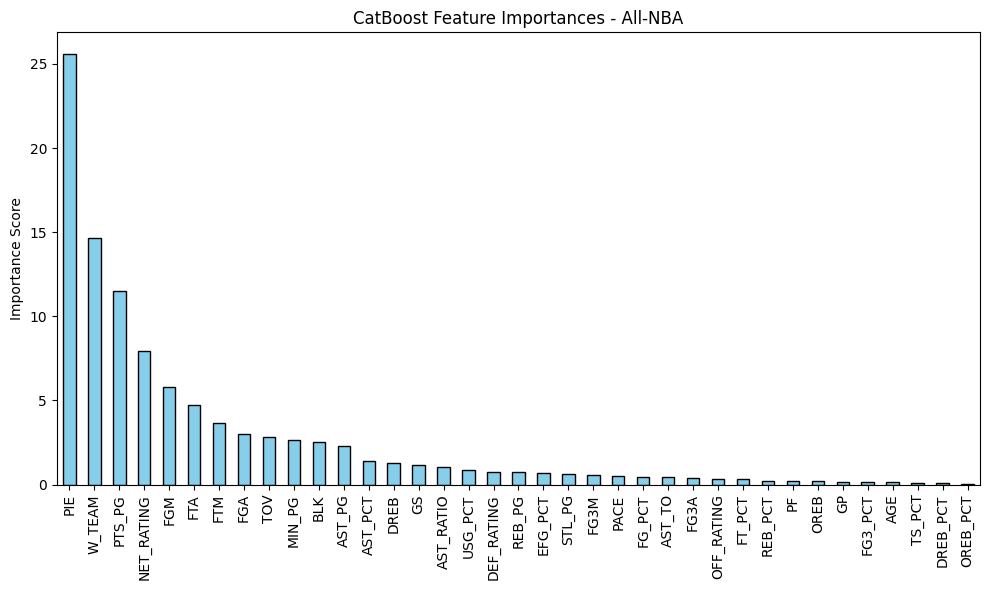

In [17]:
import matplotlib.pyplot as plt
importances = best_model_allnba.feature_importances_
feature_names = X_train_allnba.columns
list_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
list_importances.plot.bar(ax=ax, color='skyblue', edgecolor='black')
ax.set_title("CatBoost Feature Importances - All-NBA")
ax.set_ylabel("Importance Score")
fig.tight_layout()
plt.show()

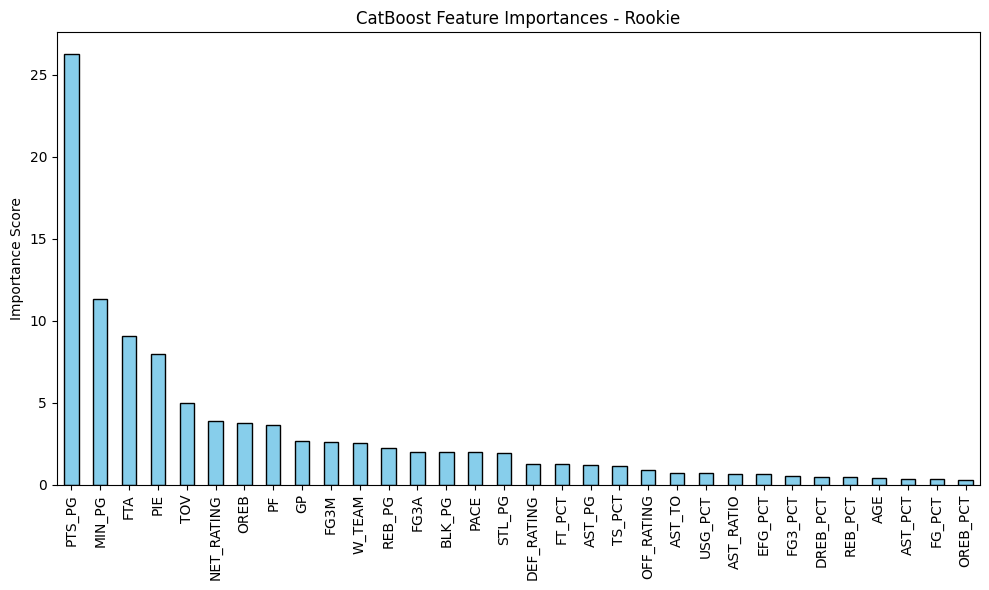

In [18]:
importances = best_model_rookie.feature_importances_
feature_names = X_train_rookie.columns
list_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
list_importances.plot.bar(ax=ax, color='skyblue', edgecolor='black')
ax.set_title("CatBoost Feature Importances - Rookie")
ax.set_ylabel("Importance Score")
fig.tight_layout()
plt.show()

### Przeszukiwanie parametrów modeli 

In [19]:
# from itertools import product
# from catboost import CatBoostRegressor

# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'depth':    [3, 4, 5, 6],
#     'learning_rate': [0.01, 0.05, 0.1],
# }

# results = []
# for params in [dict(zip(param_grid, v)) for v in product(*param_grid.values())]:
#     models = {
#         'cat': CatBoostRegressor(**params, random_state=42, verbose=0),
#     }
    
#     wyniki = models_test(
#         models_dict=models,
#         X_train=X_train_allnba, y_train=y_train_allnba,
#         X_val=X_val_allnba,     val_meta=val_allnba,
#         voting_df=df_voting_allnba,
#         seasons=val_seasons,    n_teams=3, min_games=63, show=False
#     )
#     print(f'Finished params: {params} with score: {wyniki}')
    
#     for model_name, season_scores in wyniki.items():
#         total = sum(season_scores.values())
#         results.append({'model': model_name, **params, 'score': round(total/3, 2), 'detail_results': season_scores})

# df_results = pd.DataFrame(results).sort_values('score', ascending=False)
# print(df_results.head(10))

In [20]:
# results = []

# for params in [dict(zip(param_grid, v)) for v in product(*param_grid.values())]:
#     models = {
#         'cat': CatBoostRegressor(**params, random_state=42, verbose=0),
#     }
    
#     wyniki = models_test(
#         models_dict=models,
#         X_train=X_train_rookie, y_train=y_train_rookie,
#         X_val=X_val_rookie,     val_meta=val_rookie,
#         voting_df=df_voting_rookie,
#         seasons=val_seasons,    n_teams=2, min_games=0, show=False
#     )
#     print(f'Finished params: {params} with score: {wyniki}')
    
#     for model_name, season_scores in wyniki.items():
#         total = sum(season_scores.values())
#         results.append({'model': model_name, **params, 'score': round(total/3, 2), 'detail_results': season_scores})

# df_results = pd.DataFrame(results).sort_values('score', ascending=False)
# print(df_results.head(10))


In [21]:
import os
import joblib
path_model_allnba = '../models/model_allnba.pkl'
path_model_rookie = '../models/model_rookie.pkl'

os.makedirs('../models', exist_ok=True)

if not os.path.exists(path_model_allnba):
    joblib.dump(best_model_allnba, path_model_allnba)
    print(f'Zapisano model All-NBA do: {path_model_allnba}')
else:
    print(f'Model All-NBA już istnieje pod: {path_model_allnba}')

if not os.path.exists(path_model_rookie):
    joblib.dump(best_model_rookie, path_model_rookie)
    print(f'Zapisano model Rookie do: {path_model_rookie}')
else:
    print(f'Model Rookie już istnieje pod: {path_model_rookie}')    

Model All-NBA już istnieje pod: ../models/model_allnba.pkl
Model Rookie już istnieje pod: ../models/model_rookie.pkl


In [22]:
path_final_df_allnba = '../data/final/final_model_df_allnba.csv'
path_final_df_rookie = '../data/final/final_model_df_rookie.csv'

if not os.path.exists(path_final_df_allnba):
    df_allnba.to_csv(path_final_df_allnba, index=False)
    print(f'Zapisano finalny DataFrame All-NBA do: {path_final_df_allnba}')
else:
    print(f'Finalny DataFrame All-NBA już istnieje pod: {path_final_df_allnba}')

if not os.path.exists(path_final_df_rookie):
    df_rookie.to_csv(path_final_df_rookie, index=False)
    print(f'Zapisano finalny DataFrame Rookie do: {path_final_df_rookie}')
else:
    print(f'Finalny DataFrame Rookie już istnieje pod: {path_final_df_rookie}')

Finalny DataFrame All-NBA już istnieje pod: ../data/final/final_model_df_allnba.csv
Finalny DataFrame Rookie już istnieje pod: ../data/final/final_model_df_rookie.csv
